In [ ]:
!pip uninstall -y transformers
!pip install transformers==4.44.2  # stable version with evaluation_strategy


Found existing installation: transformers 4.44.2
Uninstalling transformers-4.44.2:
  Successfully uninstalled transformers-4.44.2
  Using cached transformers-4.44.2-py3-none-any.whl.metadata (43 kB)
Using cached transformers-4.44.2-py3-none-any.whl (9.5 MB)


In [ ]:
!pip install datasets torch torchvision torchaudio scikit-learn liwc

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#EDA

In [ ]:
!pip install kaggle --quiet

In [ ]:
import os

kaggle_username = "rusheelsharma"
kaggle_key = "7c7d6601e9bd7320c7842f1904440e6c"


In [ ]:
os.environ['KAGGLE_USERNAME'] = kaggle_username
os.environ['KAGGLE_KEY'] = kaggle_key

!kaggle datasets download -d neelghoshal/reddit-mental-health-data

!unzip -o reddit-mental-health-data.zip -d reddit_mh_data

Dataset URL: https://www.kaggle.com/datasets/neelghoshal/reddit-mental-health-data
License(s): unknown
reddit-mental-health-data.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  reddit-mental-health-data.zip
  inflating: reddit_mh_data/data_to_be_cleansed.csv  


Targets given have the following mappings:

0 = Stress

1 = Depression

2 = Bipolar disorder

3 = Personality disorder

4 = Anxiety

In [ ]:

df = pd.read_csv("reddit_mh_data/data_to_be_cleansed.csv")

print("Shape:", df.shape)
print(df.head())

if 'target' in df.columns:
    print(df['target'].value_counts())


Shape: (5957, 4)
   Unnamed: 0                                               text  \
0           0  Welcome to /r/depression's check-in post - a p...   
1           1  We understand that most people who reply immed...   
2           2  Anyone else just miss physical touch? I crave ...   
3           3  I’m just so ashamed. Everyone and everything f...   
4           4  I really need a friend. I don't even have a si...   

                                               title  target  
0  Regular check-in post, with information about ...       1  
1  Our most-broken and least-understood rules is ...       1  
2  I haven’t been touched, or even hugged, in so ...       1  
3                    Being Depressed is Embarrassing       1  
4  I'm desperate for a friend and to feel loved b...       1  
target
1    1202
3    1201
4    1188
2    1185
0    1181
Name: count, dtype: int64


In [ ]:
df = df.drop(columns=['Unnamed: 0'])  # drop index col
df['text_full'] = df['title'].astype(str) + " " + df['text'].astype(str)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5957 entries, 0 to 5956
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       5607 non-null   object
 1   title      5957 non-null   object
 2   target     5957 non-null   int64 
 3   text_full  5957 non-null   object
dtypes: int64(1), object(3)
memory usage: 186.3+ KB
None
target
1    1202
3    1201
4    1188
2    1185
0    1181
Name: count, dtype: int64


/tmp/ipython-input-3539828674.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


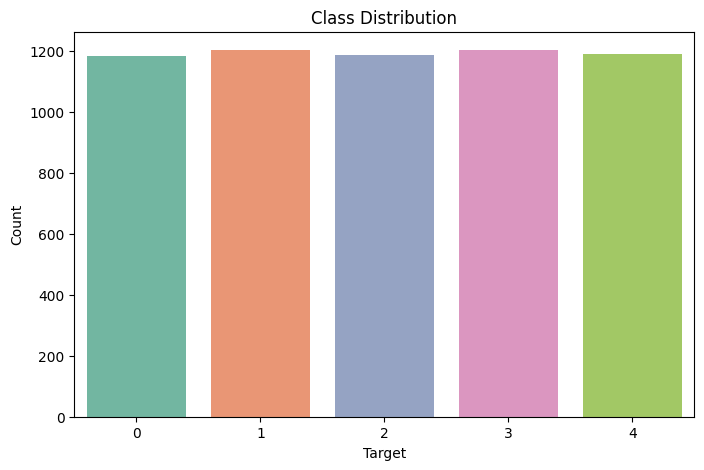

In [ ]:
print(df.info())
print(df['target'].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Class Distribution')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

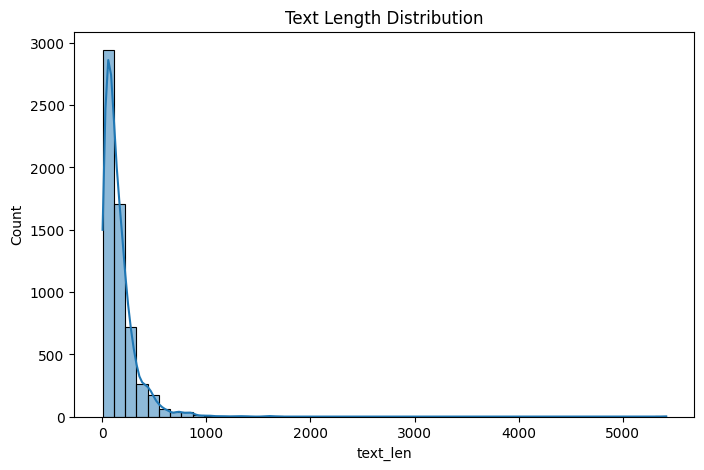

In [ ]:
df['text_len'] = df['text_full'].apply(lambda x: len(x.split()))
plt.figure(figsize=(8,5))
sns.histplot(df['text_len'], bins=50, kde=True)
plt.title('Text Length Distribution')
plt.show()

In [ ]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['text_full'], df['target'], test_size=0.2, random_state=42, stratify=df['target']
)

In [ ]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True, max_length=128)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [ ]:
class MH_Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.encodings['input_ids'][idx]),
            'attention_mask': torch.tensor(self.encodings['attention_mask'][idx]),
            'labels': torch.tensor(self.labels.iloc[idx], dtype=torch.long)
        }

train_dataset = MH_Dataset(train_encodings, train_labels)
test_dataset = MH_Dataset(test_encodings, test_labels)

#Model

In [ ]:
num_labels = df['target'].nunique()
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=num_labels)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


lr = 0.00002

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    eval_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs'
)


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {'accuracy': (preds == labels).mean()}

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()
#6b14fd14fcf362d41c53feabc688540acc52de53

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: rusheelhere (rusheelhere-na) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.714564,0.758389
2,0.861200,0.625630,0.791946
3,0.861200,0.618008,0.802013


TrainOutput(global_step=894, training_loss=0.6812279379074472, metrics={'train_runtime': 219.9485, 'train_samples_per_second': 64.992, 'train_steps_per_second': 4.065, 'total_flos': 473430693484800.0, 'train_loss': 0.6812279379074472, 'epoch': 3.0})

In [ ]:
preds_output = trainer.predict(test_dataset)
preds = np.argmax(preds_output.predictions, axis=1)

print("\nClassification Report:")
print(classification_report(test_labels, preds, target_names=['Stress','Depression','Bipolar','Personality','Anxiety']))



Classification Report:
              precision    recall  f1-score   support

      Stress       0.84      0.86      0.85       236
  Depression       0.74      0.73      0.74       241
     Bipolar       0.88      0.81      0.84       237
 Personality       0.77      0.78      0.78       240
     Anxiety       0.78      0.83      0.81       238

    accuracy                           0.80      1192
   macro avg       0.80      0.80      0.80      1192
weighted avg       0.80      0.80      0.80      1192



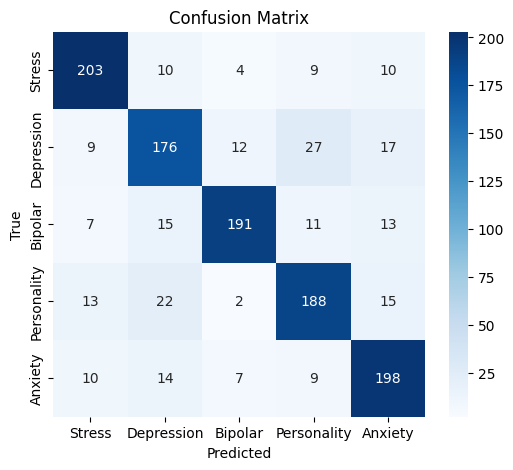

In [ ]:
cm = confusion_matrix(test_labels, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stress','Depression','Bipolar','Personality','Anxiety'],
            yticklabels=['Stress','Depression','Bipolar','Personality','Anxiety'])
plt.ylabel('True')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

#load

In [ ]:
# Re-save model weights and config
trainer.save_model("./mental_health_model")
tokenizer.save_pretrained("./mental_health_model")


('./mental_health_model/tokenizer_config.json',
 './mental_health_model/special_tokens_map.json',
 './mental_health_model/vocab.txt',
 './mental_health_model/added_tokens.json',
 './mental_health_model/tokenizer.json')

In [ ]:
!ls ./mental_health_model


config.json	   special_tokens_map.json  tokenizer.json     vocab.txt
model.safetensors  tokenizer_config.json    training_args.bin


In [ ]:
from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast

model_path = "./mental_health_model"
model = DistilBertForSequenceClassification.from_pretrained(model_path)
tokenizer = DistilBertTokenizerFast.from_pretrained(model_path)


#Multi-Label

In [ ]:

import torch
from torch.nn.functional import sigmoid
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification


model_path = "./mental_health_model"
tokenizer = DistilBertTokenizerFast.from_pretrained(model_path)
model = DistilBertForSequenceClassification.from_pretrained(model_path)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


labels = ['Stress','Depression','Bipolar','Personality','Anxiety']

def predict_multilabel(text, threshold=0.5):

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(**inputs).logits
        probs = sigmoid(logits).cpu().numpy()[0]
    predicted_labels = [labels[i] for i, s in enumerate(probs) if s >= threshold]
    return dict(zip(labels, probs)), predicted_labels


sample = "I've been feeling anxious and stressed about everything lately."
scores, predictions = predict_multilabel(sample)
print("Confidence scores:", scores)
print("Predicted labels:", predictions)


Confidence scores: {'Stress': np.float32(0.8679868), 'Depression': np.float32(0.1858774), 'Bipolar': np.float32(0.1278654), 'Personality': np.float32(0.25414053), 'Anxiety': np.float32(0.90165037)}
Predicted labels: ['Stress', 'Anxiety']


In [ ]:
sample = "I like NMIMS"
scores, predictions = predict_multilabel(sample)
print("Confidence scores:", scores)
print("Predicted labels:", predictions)

Confidence scores: {'Stress': np.float32(0.55945927), 'Depression': np.float32(0.39115214), 'Bipolar': np.float32(0.39329582), 'Personality': np.float32(0.737729), 'Anxiety': np.float32(0.3661718)}
Predicted labels: ['Stress', 'Personality']


In [ ]:
from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast
import shutil

# === 1. Save DistilBERT model and tokenizer ===
distil_save_path = "./distilbert_model"
trainer.save_model(distil_save_path)                     # saves model weights/config
tokenizer.save_pretrained(distil_save_path)              # saves tokenizer files

'''# === 2. Save BioClinicalBERT model and tokenizer ===
bio_save_path = "./bioclinicalbert_model"
bio_trainer.save_model(bio_save_path)
bio_tokenizer.save_pretrained(bio_save_path)'''

# === 3. (Optional) Compress to zip for download ===
shutil.make_archive(distil_save_path, 'zip', distil_save_path)
#shutil.make_archive(bio_save_path, 'zip', bio_save_path)

print("Models and tokenizers saved and zipped successfully!")

Models and tokenizers saved and zipped successfully!


In [ ]:
from google.colab import files
files.download("./distilbert_model.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#MentalBERT

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer


mental_model_name = "mental/mental-bert-base-uncased"

mental_tokenizer = AutoTokenizer.from_pretrained(mental_model_name)
mental_model = AutoModelForSequenceClassification.from_pretrained(
    mental_model_name,
    num_labels=5,
    problem_type="multi_label_classification"
)


def tokenize_mental(examples):
    return mental_tokenizer(examples["text"], padding="max_length", truncation=True)

tokenized_train = train_dataset.map(tokenize_mental, batched=True)
tokenized_test = test_dataset.map(tokenize_mental, batched=True)


mental_training_args = TrainingArguments(
    output_dir="./mentalbert_results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch"
)


mental_trainer = Trainer(
    model=mental_model,
    args=mental_training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    tokenizer=mental_tokenizer,
    compute_metrics=compute_metrics
)


mental_trainer.train()


mental_metrics = mental_trainer.evaluate()
print("MentalBERT/MentalRoBERTa metrics:", mental_metrics)


mental_trainer.save_model("./mentalbert_model")
mental_tokenizer.save_pretrained("./mentalbert_model")


OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/mental/mental-bert-base-uncased.
401 Client Error. (Request ID: Root=1-68ce2944-3feaab06633a5e750e4c3079;d2132f65-8fa9-4b35-adcf-d6d187650b28)

Cannot access gated repo for url https://huggingface.co/mental/mental-bert-base-uncased/resolve/main/config.json.
Access to model mental/mental-bert-base-uncased is restricted. You must have access to it and be authenticated to access it. Please log in.